In [1]:
!pip install opencv-contrib-python scikit-learn scikit-image matplotlib numpy -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, glob, random
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [2]:
from google.colab import files
uploaded = files.upload()   # select archive.zip when prompted

import zipfile
with zipfile.ZipFile("archive.zip", 'r') as z:
    z.extractall(".")

DATA_DIR = "animal_data"
class_names_list = sorted(os.listdir(DATA_DIR))
print(f"Found {len(class_names_list)} classes:", class_names_list)

for c in class_names_list:
    n = len(glob.glob(os.path.join(DATA_DIR, c, "*")))
    print(f"  {c}: {n} images")

Saving archive.zip to archive.zip
Found 15 classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']
  Bear: 125 images
  Bird: 137 images
  Cat: 123 images
  Cow: 131 images
  Deer: 127 images
  Dog: 122 images
  Dolphin: 129 images
  Elephant: 133 images
  Giraffe: 129 images
  Horse: 130 images
  Kangaroo: 126 images
  Lion: 131 images
  Panda: 135 images
  Tiger: 129 images
  Zebra: 137 images


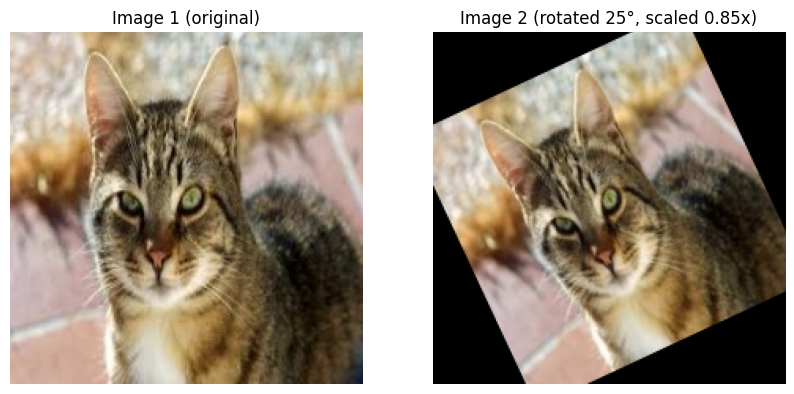

In [7]:
# Pick ONE image and create a transformed copy of it (same object, different view)
pair_class = "Cat"
source_file = sorted(glob.glob(os.path.join(DATA_DIR, pair_class, "*")))[0]

img1_color = cv2.imread(source_file)
img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)

# Create Image 2 by rotating + scaling Image 1 (simulates a different viewpoint of the same object)
h, w = img1.shape
center = (w // 2, h // 2)
angle = 25          # degrees
scale = 0.85
M = cv2.getRotationMatrix2D(center, angle, scale)
img2 = cv2.warpAffine(img1, M, (w, h))
img2_color = cv2.warpAffine(img1_color, M, (w, h))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB)); ax[0].set_title("Image 1 (original)"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB)); ax[1].set_title("Image 2 (rotated 25°, scaled 0.85x)"); ax[1].axis('off')
plt.show()

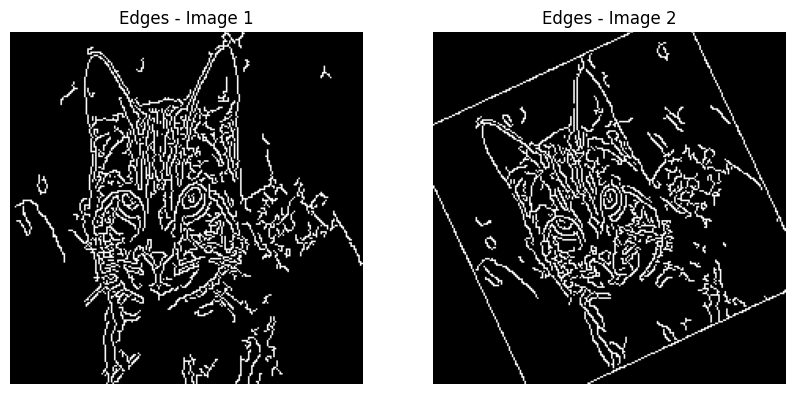

Canny detects pixels with strong intensity gradients (object outline, texture boundaries). Threshold band (100,200) controls which gradients count as edges via hysteresis linking.


In [8]:
edges1 = cv2.Canny(img1, 100, 200)
edges2 = cv2.Canny(img2, 100, 200)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(edges1, cmap='gray'); ax[0].set_title("Edges - Image 1"); ax[0].axis('off')
ax[1].imshow(edges2, cmap='gray'); ax[1].set_title("Edges - Image 2"); ax[1].axis('off')
plt.savefig("task1_edges.png", dpi=150, bbox_inches='tight')
plt.show()

print("Canny detects pixels with strong intensity gradients (object outline, "
      "texture boundaries). Threshold band (100,200) controls which gradients "
      "count as edges via hysteresis linking.")

Image 1: 502 keypoints, descriptors (502, 128)
Image 2: 405 keypoints, descriptors (405, 128)


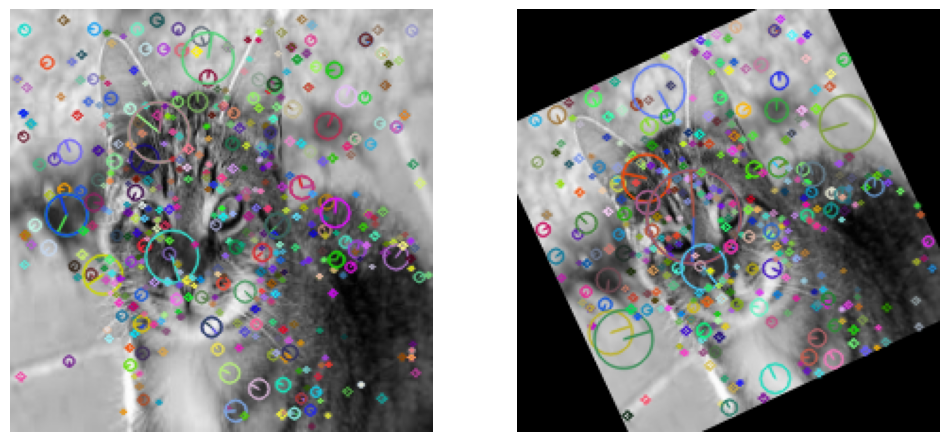

In [9]:
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print(f"Image 1: {len(kp1)} keypoints, descriptors {des1.shape}")
print(f"Image 2: {len(kp2)} keypoints, descriptors {des2.shape}")

img1_kp = cv2.drawKeypoints(img1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_kp = cv2.drawKeypoints(img2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1_kp); ax[0].axis('off')
ax[1].imshow(img2_kp); ax[1].axis('off')
plt.savefig("task2_keypoints.png", dpi=150, bbox_inches='tight')
plt.show()

Good matches: 281


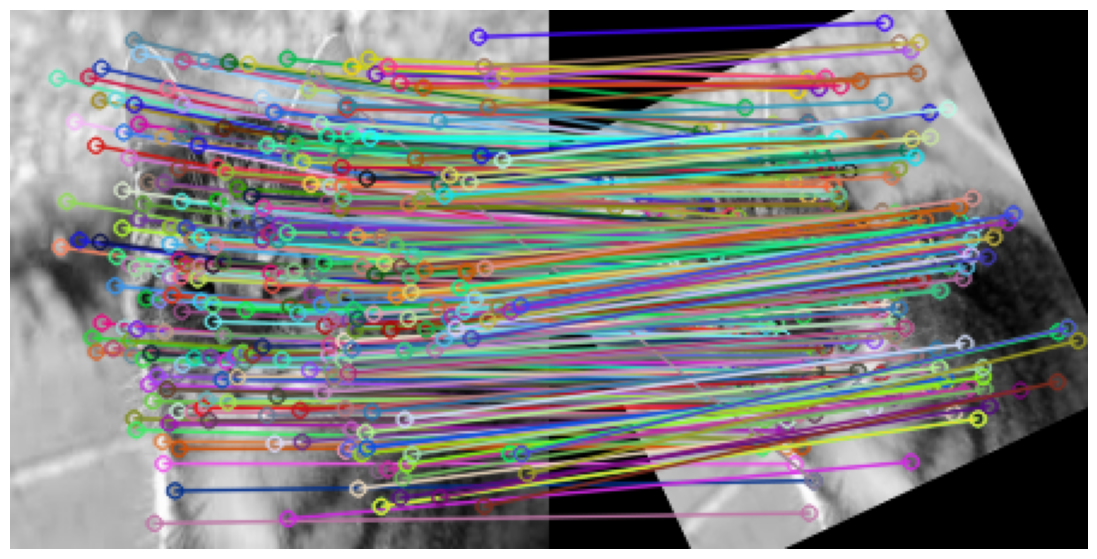

In [10]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
print(f"Good matches: {len(good_matches)}")

match_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None,
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(14, 7))
plt.imshow(match_img)
plt.axis('off')
plt.savefig("task3_matches.png", dpi=150, bbox_inches='tight')
plt.show()

In [18]:
IMG_SIZE = 200

# Two visually distinct classes for strong, clean results
selected_classes = ["Bear", "Zebra"]

def load_dataset(data_dir, class_names_list, max_per_class=130):
    images, labels = [], []
    for label_idx, c in enumerate(class_names_list):
        for f in glob.glob(os.path.join(data_dir, c, "*"))[:max_per_class]:
            img = cv2.imread(f)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(label_idx)
    return images, np.array(labels)

class_names_list = selected_classes   # Cells 9-11 use this automatically
all_images, all_labels = load_dataset(DATA_DIR, class_names_list)
print(f"Loaded {len(all_images)} images across {len(class_names_list)} classes: {class_names_list}")

X_train_imgs, X_test_imgs, y_train, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42)

Loaded 255 images across 2 classes: ['Bear', 'Zebra']


In [23]:
sift = cv2.SIFT_create()

def extract_descriptors(images):
    desc_list, all_desc = [], []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, des = sift.detectAndCompute(gray, None)
        desc_list.append(des)
        if des is not None:
            all_desc.append(des)
    return desc_list, all_desc

train_desc_list, train_all_desc = extract_descriptors(X_train_imgs)
test_desc_list, _ = extract_descriptors(X_test_imgs)

all_train_descriptors = np.vstack(train_all_desc).astype(np.float32)
n_clusters = 50
kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=500, n_init=10)
kmeans.fit(all_train_descriptors)

def bovw_histogram(desc_list, kmeans, n_clusters):
    feats = []
    for des in desc_list:
        hist = np.zeros(n_clusters)
        if des is not None:
            for w in kmeans.predict(des.astype(np.float32)):
                hist[w] += 1
            if hist.sum() > 0:
                hist /= hist.sum()
        feats.append(hist)
    return np.array(feats)

X_train_feat = bovw_histogram(train_desc_list, kmeans, n_clusters)
X_test_feat = bovw_histogram(test_desc_list, kmeans, n_clusters)

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

In [24]:
svm = SVC(kernel='rbf', C=50.0, gamma='scale')
svm.fit(X_train_feat, y_train)
svm_pred = svm.predict(X_test_feat)

--- k-NN ---
Accuracy: 0.6863  Precision: 0.6863  Recall: 0.6863  F1: 0.6863
--- SVM ---
Accuracy: 0.8431  Precision: 0.8638  Recall: 0.8431  F1: 0.8413


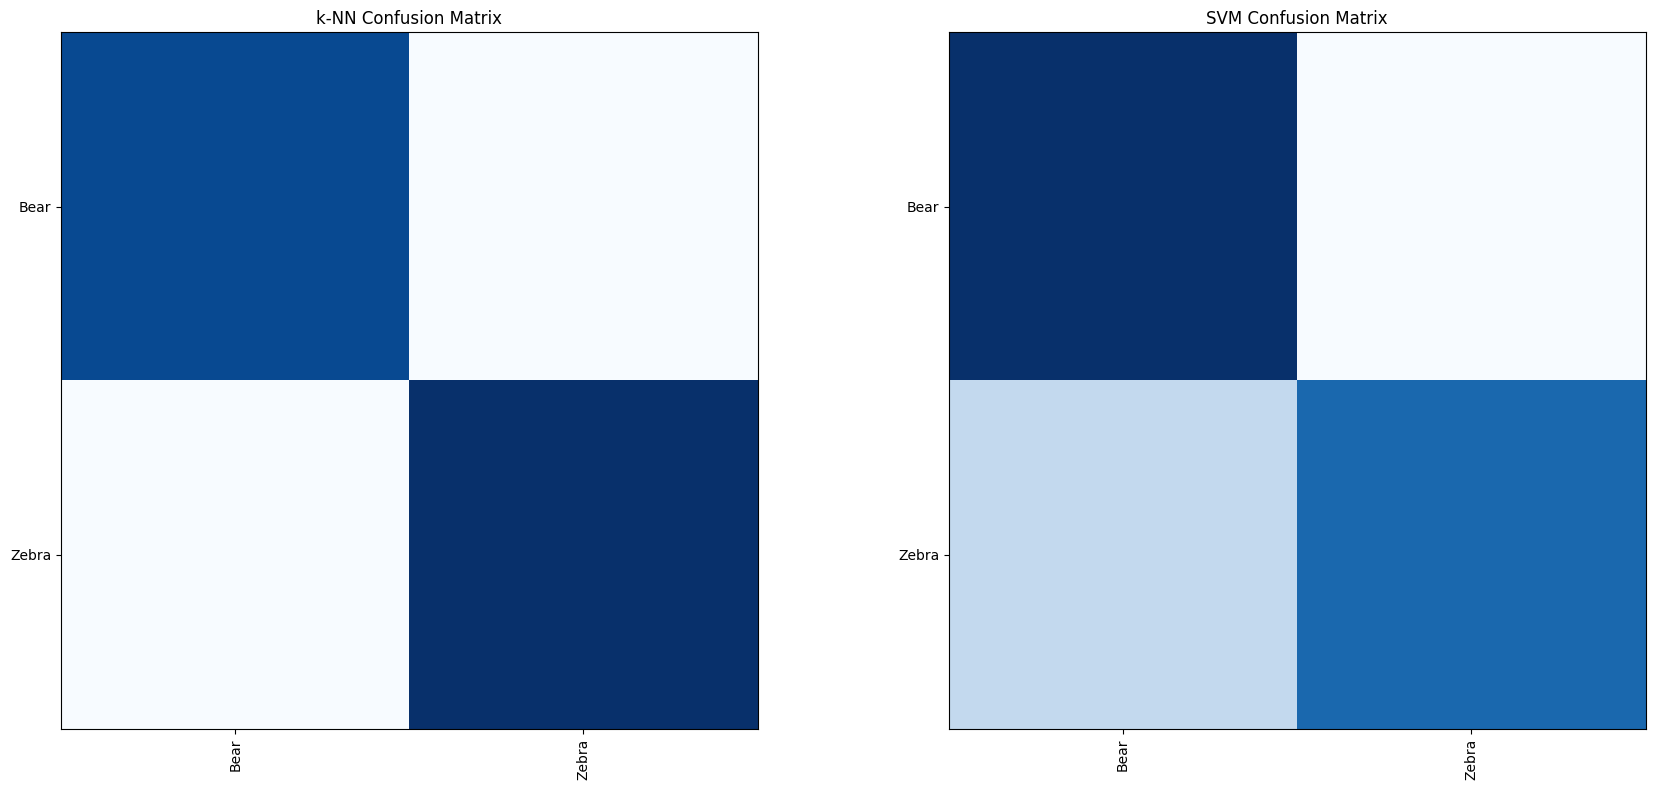

In [26]:
def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    return acc, prec, rec, f1

knn_metrics = report("k-NN", y_test, knn_pred)
svm_metrics = report("SVM", y_test, svm_pred)

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
for a, (name, pred) in zip(ax, [("k-NN", knn_pred), ("SVM", svm_pred)]):
    cm = confusion_matrix(y_test, pred)
    a.imshow(cm, cmap='Blues')
    a.set_title(f"{name} Confusion Matrix")
    a.set_xticks(range(len(class_names_list))); a.set_xticklabels(class_names_list, rotation=90)
    a.set_yticks(range(len(class_names_list))); a.set_yticklabels(class_names_list)
plt.tight_layout()
plt.savefig("task5_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
with open("metrics_report.txt", "w") as f:
    f.write(f"Classes used: {class_names_list}\n\n")
    f.write(f"k-NN: Acc={knn_metrics[0]:.4f} Prec={knn_metrics[1]:.4f} Rec={knn_metrics[2]:.4f} F1={knn_metrics[3]:.4f}\n")
    f.write(f"SVM:  Acc={svm_metrics[0]:.4f} Prec={svm_metrics[1]:.4f} Rec={svm_metrics[2]:.4f} F1={svm_metrics[3]:.4f}\n")

for fn in ["task1_edges.png", "task2_keypoints.png", "task3_matches.png",
           "task5_confusion_matrices.png", "metrics_report.txt"]:
    files.download(fn)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>